# Refining an adaptive Morse graph with fixed-subdivision reachability

A Conley-Morse graph carries two kinds of information: the Morse sets, and the
reachability relation between them.  The Morse sets are strongly connected
components of a combinatorial multivalued map.  The *edges*, however, are
accumulated across the adaptive subdivision hierarchy — when a coarse Morse set
is refined into several finer ones, the relations recorded at the coarse level
are inherited by the descendants as a cross product.  That inheritance is sound
as an outer approximation, but it can record an edge $M_i \to M_j$ that no path
in the finer combinatorial map realises.

This notebook exhibits exactly that situation on the two-dimensional Leslie
model, and detects it with `CMGDB.ComputeMorseSetReachability`.  For a chosen
subdivision depth $s$ the verifier exhausts the forward closure of each Morse
set on the *conceptual* uniform grid at depth $s$, deciding every ordered pair
as `REACHABLE`, `NOT_REACHABLE`, or `INCOMPLETE`.  It never materialises a
complete `TreeGrid` or `MapGraph`.

Three distinct notions of reachability appear below, and they are not
interchangeable:

1. **Adaptive Morse-graph reachability** — the relation stored in the
   `MorseGraph` returned by `CMGDB.ComputeConleyMorseGraph`, including edges
   inherited from coarser levels of the hierarchy.
2. **Fixed-subdivision combinatorial reachability** — existence of a path in the
   multivalued map $\mathcal{F}_s(x) = \mathrm{cover}_s(f(\mathrm{geo}_s(x)))$ on
   the uniform grid at depth $s$.  This is what the verifier decides.
3. **Reachability of the true continuous dynamics** — whether a genuine orbit of
   the Leslie map connects the two invariant sets.

The verifier addresses items 1 and 2 only.  Nothing here resolves item 3, and
the closing section states the logical relationship between them precisely.

The map is the standard 2-D Leslie model used throughout the CMGDB examples,

$$
f(x_0, x_1) =
\begin{pmatrix}
(\theta_0 x_0 + \theta_1 x_1)\, e^{-0.1 (x_0 + x_1)} \\
0.7\, x_0
\end{pmatrix},
\qquad
\theta_0 = 19.6, \quad \theta_1 = 23.68 ,
$$

at parameters chosen so that the adaptive relation is a chain, one of whose
edges is absent from every fixed grid we test.  This cell is self-contained so
the notebook runs independently of the other examples.


## Feature guard

The verifier is a fork-specific addition and is absent from released upstream
CMGDB, so we check for it before doing any work.  This notebook must run against
a CMGDB built from the current working tree.


In [1]:
import hashlib
import math
import shutil
import sys
import time
from decimal import Decimal, getcontext

import matplotlib.pyplot as plt
import graphviz

import CMGDB

REQUIRED_API = [
    "ComputeMorseSetReachability",
    "ComputeMorseSetReachabilityStudy",
    "MorseSetReachabilityStatus",
    "MorseSetRelationDiagnostic",
]

missing = [name for name in REQUIRED_API if not hasattr(CMGDB, name)]
if missing:
    raise RuntimeError(
        "This notebook requires the fixed-subdivision Morse-set reachability "
        f"API, missing from the installed CMGDB: {', '.join(missing)}. "
        "Build CMGDB from the current working tree "
        "(python setup.py build_ext --inplace) and restart the kernel."
    )

# The Morse-graph figures render through graphviz, which shells out to `dot`.
if shutil.which("dot") is None:
    raise RuntimeError(
        "graphviz's `dot` executable is not on PATH; the Morse-graph figures "
        "cannot render.  Install graphviz (e.g. `brew install graphviz`)."
    )

STATUS = CMGDB.MorseSetReachabilityStatus
DIAGNOSTIC = CMGDB.MorseSetRelationDiagnostic
STOP_REASON = CMGDB.MorseSetReachabilityStopReason

print("Fixed-subdivision Morse-set reachability API available.")


Fixed-subdivision Morse-set reachability API available.


## CMGDB parameters

`SUBDIV_INIT` is the depth at which the adaptive computation starts, and it is
the parameter that produces the phenomenon studied here — a later section shows
that raising it alone removes the offending edge.  `SUBDIV_LIMIT` caps the number
of boxes and, as we will confirm, is what actually halts refinement in this run:
every Morse-set leaf ends up at depth 16 rather than at `SUBDIV_MAX`.  That makes
$s = 16$ the adaptive computation's *own* final grid, and therefore the sharpest
of the depths we verify rather than the coarsest.

The map fingerprint is derived from the parameters and the enclosure version, so
changing $\theta$ changes it.  It identifies the map for provenance and
checkpoint-resume purposes; note that no automatic scheme can detect every edit
to the enclosure body, so the version tag must be bumped by hand when that code
changes.


In [2]:
THETA_0  = 19.6
THETA_1  = 23.68
DECAY    = 0.1
SURVIVAL = 0.7

LOWER_BOUNDS = [-0.001, -0.001]
UPPER_BOUNDS = [ 90.0,   70.0]

SUBDIV_INIT  = 8
SUBDIV_MIN   = 16
SUBDIV_MAX   = 20
SUBDIV_LIMIT = 10_000

PHASE_SUBDIVISIONS = list(range(SUBDIV_MIN, SUBDIV_MAX + 1))
BATCH_SIZE = 4096

ENCLOSURE_VERSION = "corner+edge-critical, error-bounded, v2"
MAP_FINGERPRINT = "leslie-2d-" + hashlib.sha256(
    repr((THETA_0, THETA_1, DECAY, SURVIVAL, ENCLOSURE_VERSION)).encode()
).hexdigest()[:16]

print(f"map fingerprint: {MAP_FINGERPRINT}")


map fingerprint: leslie-2d-03a1c24172f51ba9


## A rigorous rectangle enclosure

The verifier is only as sound as the rectangle map it is given, so the box map
must return a genuine outer enclosure of $f(R)$ for every rectangle $R$ — not a
sample.  Four-corner evaluation is **not** sufficient here.

Write $g(x, y) = (a x + b y) e^{-0.1(x+y)}$ with $a = 19.6$, $b = 23.68$.  Then

$$
\partial_x g = \bigl(a - 0.1(ax+by)\bigr) e^{-0.1(x+y)},
\qquad
\partial_y g = \bigl(b - 0.1(ax+by)\bigr) e^{-0.1(x+y)} .
$$

The exponential never vanishes, so $\partial_x g = 0$ exactly on the line
$ax + by = 10a$ and $\partial_y g = 0$ exactly on $ax + by = 10b$.  Since
$a \neq b$ these lines are disjoint: $g$ has **no interior stationary point**,
and its extrema over a closed rectangle are attained on the boundary.  On a
horizontal edge $y = \mathrm{const}$ the restriction of $g$ is stationary only at
$x^{*} = 10 - (b/a)y$, and on a vertical edge $x = \mathrm{const}$ only at
$y^{*} = 10 - (a/b)x$.  Evaluating the four corners together with these
edge-interior critical points, whenever they lie in the rectangle, therefore
gives the exact range of $g$ over $R$.

The second component $0.7x$ is monotone, so $0.7\,[x_{\min}, x_{\max}]$ is exact.
(Incidentally, $g$ is concave along each edge, so every edge-interior critical
point is a local *maximum*; the minimum is always attained at a corner.  The
critical points are therefore only needed for the upper bound, but evaluating
them for both costs nothing.)

**Exact arithmetic is not enough.**  The argument above gives the exact range in
exact arithmetic, but the values are computed in floating point, and a one-ulp
`math.nextafter` margin does *not* cover the evaluation error.  The reason is
the exponential: writing $t = -0.1(x+y)$, the computed $\hat{t}$ carries relative
error up to $2u$ ($u = 2^{-53}$), and

$$
e^{\hat{t}} = e^{t(1+\delta)} = e^{t} \cdot e^{t\delta}
\approx e^{t}\bigl(1 + t\delta\bigr),
$$

so the *relative* error of the exponential is amplified by $|t|$, which reaches
$0.1 \cdot 160 = 16$ on this domain.  The result is a relative error of order
$10^{-15}$ — tens of ulps, not one.  Accordingly each candidate value is widened
by a certified bound

$$
\bigl|\hat{g} - g\bigr| \;\le\;
\underbrace{2u\bigl(|ax| + |by|\bigr)e^{t}}_{\text{error in } ax+by}
\;+\;
\underbrace{|ax + by|\,e^{t}\,(2|t| + 1)u}_{\text{error in } e^{t}}
\;+\;
\underbrace{|g|\,u}_{\text{final product}},
$$

carried through a safety factor, *before* the minimum and maximum are taken; the
`math.nextafter` step is then applied on top.  The cell after next verifies this
against a 60-digit reference, and shows that the one-ulp version fails.


In [3]:
UNIT_ROUNDOFF = sys.float_info.epsilon / 2.0   # u = 2^-53
ERROR_SAFETY = 4.0                             # slack over the derived bound


def leslie_first_component(x, y):
    """First Leslie component g(x, y) = (a x + b y) exp(-0.1 (x + y))."""
    return (THETA_0 * x + THETA_1 * y) * math.exp(-DECAY * (x + y))


def leslie_first_component_bounded(x, y):
    """g(x, y) in floating point, with a certified absolute error bound."""
    scale = THETA_0 * x + THETA_1 * y
    argument = -DECAY * (x + y)
    factor = math.exp(argument)
    value = scale * factor

    error_scale = 2.0 * UNIT_ROUNDOFF * (abs(THETA_0 * x) + abs(THETA_1 * y))
    relative_factor = (2.0 * abs(argument) + 1.0) * UNIT_ROUNDOFF
    bound = ERROR_SAFETY * (
        error_scale * factor
        + abs(scale) * factor * relative_factor
        + abs(value) * UNIT_ROUNDOFF
    )
    return value, bound


def leslie_candidates(rect):
    """Corners plus the edge-interior critical points of g inside rect."""
    x_min, y_min, x_max, y_max = rect
    candidates = [(x, y) for x in (x_min, x_max) for y in (y_min, y_max)]
    for y in (y_min, y_max):
        x_star = 10.0 - (THETA_1 / THETA_0) * y
        if x_min <= x_star <= x_max:
            candidates.append((x_star, y))
    for x in (x_min, x_max):
        y_star = 10.0 - (THETA_0 / THETA_1) * x
        if y_min <= y_star <= y_max:
            candidates.append((x, y_star))
    return candidates


def leslie_box_map(rect):
    """Rigorous outer enclosure of the Leslie map on a rectangle.

    rect is [x_min, y_min, x_max, y_max]; the result is an enclosure
    [g_min, h_min, g_max, h_max] of the image.  Each candidate value is
    widened by its certified floating-point error bound before the
    extremes are taken, then rounded outward one further ulp.
    """
    x_min, y_min, x_max, y_max = rect

    lows, highs = [], []
    for x, y in leslie_candidates(rect):
        value, bound = leslie_first_component_bounded(x, y)
        lows.append(value - bound)
        highs.append(value + bound)

    return [
        math.nextafter(min(lows), -math.inf),
        math.nextafter(SURVIVAL * x_min, -math.inf),
        math.nextafter(max(highs), math.inf),
        math.nextafter(SURVIVAL * x_max, math.inf),
    ]


def leslie_box_map_one_ulp(rect):
    """The naive variant: exact-arithmetic extremes, one ulp of margin.

    Kept only to demonstrate below that this is not a valid enclosure.
    """
    values = [leslie_first_component(x, y) for x, y in leslie_candidates(rect)]
    x_min, x_max = rect[0], rect[2]
    return [
        math.nextafter(min(values), -math.inf),
        math.nextafter(SURVIVAL * x_min, -math.inf),
        math.nextafter(max(values), math.inf),
        math.nextafter(SURVIVAL * x_max, math.inf),
    ]


def leslie_box_map_batch(rects):
    """Pointwise-identical batch callback: the same enclosure, per rectangle."""
    return [leslie_box_map(rect) for rect in rects]


An enclosure bug would silently invalidate every conclusion below, so we test it
directly — and the test must not be circular.  Comparing the enclosure against
the same floating-point `leslie_first_component` that built it can never fail,
because both sides commit the identical rounding error.  We therefore evaluate
the reference with `decimal` at 60 significant digits, which is far beyond
double precision, and check containment against *that*.

Sample points are taken at the exact rectangle corners rather than interpolated
to them, since interpolation can overshoot a corner by one unit in the last place
and report a spurious violation for a point that is genuinely outside $R$.


In [4]:
SAMPLE_RECTS = [
    [-0.001, -0.001, 90.0, 70.0],   # the whole domain
    [  0.0,    0.0,  12.0,  9.0],   # straddles both critical lines
    [  5.0,    3.0,   5.7,  3.9],   # small interior box
    [ 30.0,   20.0,  45.0, 33.0],   # far side of the critical lines
    [  0.0,   60.0,   1.0, 70.0],   # thin box near the top edge
]
SAMPLES_PER_AXIS = 21
getcontext().prec = 60


def leslie_first_component_exact(x, y):
    """g(x, y) evaluated at 60 significant digits, as a Decimal."""
    big_x, big_y = Decimal(x), Decimal(y)
    scale = Decimal(THETA_0) * big_x + Decimal(THETA_1) * big_y
    return scale * (-Decimal(DECAY) * (big_x + big_y)).exp()


def sample_coordinate(low, high, index, count):
    """Sample point that is never outside [low, high] by a rounding step."""
    if index == 0:
        return low
    if index == count - 1:
        return high
    return min(max(low + (high - low) * index / (count - 1), low), high)


n_samples = 0

for rect in SAMPLE_RECTS:
    x_min, y_min, x_max, y_max = rect
    g_min, h_min, g_max, h_max = leslie_box_map(rect)
    for i in range(SAMPLES_PER_AXIS):
        for j in range(SAMPLES_PER_AXIS):
            x = sample_coordinate(x_min, x_max, i, SAMPLES_PER_AXIS)
            y = sample_coordinate(y_min, y_max, j, SAMPLES_PER_AXIS)
            exact = leslie_first_component_exact(x, y)
            n_samples += 1
            assert Decimal(g_min) <= exact <= Decimal(g_max), (
                f"enclosure misses the exact g{(x, y)} = {exact} "
                f"for rect {rect}"
            )
            assert h_min <= SURVIVAL * x <= h_max, (
                f"enclosure misses 0.7*{x} for rect {rect}"
            )

assert leslie_box_map_batch(SAMPLE_RECTS) == [
    leslie_box_map(rect) for rect in SAMPLE_RECTS
], "batch callback disagrees with the scalar callback"

print(f"Enclosure contains the 60-digit exact image at all {n_samples} "
      f"sampled points across {len(SAMPLE_RECTS)} rectangles.")
print("Batch callback is pointwise identical to the scalar callback.")

# The widening must be negligible against the grid, or it would blunt the
# analysis rather than merely making it sound.
widest = max(
    leslie_first_component_bounded(x, y)[1]
    for rect in SAMPLE_RECTS
    for x, y in leslie_candidates(rect)
)
cell_width = (UPPER_BOUNDS[0] - LOWER_BOUNDS[0]) / 2 ** (SUBDIV_MAX // 2)
print(f"Largest error widening {widest:.3e} is {widest / cell_width:.1e} of a "
      f"depth-{SUBDIV_MAX} cell width ({cell_width:.4f}).")


Enclosure contains the 60-digit exact image at all 2205 sampled points across 5 rectangles.
Batch callback is pointwise identical to the scalar callback.
Largest error widening 2.321e-13 is 2.6e-12 of a depth-20 cell width (0.0879).


Passing that test on well-behaved rectangles is necessary but not sufficient,
and it does not by itself show the one-ulp margin was inadequate.  The following
point does.  It is a degenerate rectangle — a single point, so the true image is
a single value — chosen where $x + y \approx 128$ and the exponential's argument
error is most strongly amplified.


In [5]:
PROBE_X, PROBE_Y = 62.48817722746601, 65.85392009332787
probe_rect = [PROBE_X, PROBE_Y, PROBE_X, PROBE_Y]

exact_value = leslie_first_component_exact(PROBE_X, PROBE_Y)
naive_low, _, naive_high, _ = leslie_box_map_one_ulp(probe_rect)
safe_low, _, safe_high, _ = leslie_box_map(probe_rect)

naive_contains = Decimal(naive_low) <= exact_value <= Decimal(naive_high)
safe_contains = Decimal(safe_low) <= exact_value <= Decimal(safe_high)

assert not naive_contains, "the one-ulp variant unexpectedly contains the image"
assert safe_contains, "the error-bounded enclosure misses the image"

deficit = Decimal(naive_low) - exact_value
print(f"f({PROBE_X}, {PROBE_Y})")
print(f"  exact first component : {exact_value:.24f}")
print(f"  one-ulp enclosure     : [{naive_low!r}, {naive_high!r}]")
print(f"     contains the image : {naive_contains}  "
      f"(low bound too high by {float(deficit):.3e} = "
      f"{float(deficit / Decimal(math.ulp(float(exact_value)))):.1f} ulp)")
print(f"  error-bounded enclosure: [{safe_low!r}, {safe_high!r}]")
print(f"     contains the image : {safe_contains}")


f(62.48817722746601, 65.85392009332787)
  exact first component : 0.007428006291056923111946
  one-ulp enclosure     : [0.007428006291056938, 0.00742800629105694]
     contains the image : False  (low bound too high by 1.501e-17 = 17.3 ulp)
  error-bounded enclosure: [0.00742800629105684, 0.007428006291057038]
     contains the image : True


One consequence of the argument above is worth recording now, because it
qualifies the closing interpretation: applied to the whole domain the enclosure
is *exact*, so it reports the true range of each component over the phase space.
That range is not contained in the phase space.  The truncated domain is
therefore **not forward invariant**, and `cover` clips the part of an image that
falls outside it.


In [6]:
domain_image = leslie_box_map(LOWER_BOUNDS + UPPER_BOUNDS)
g_low, h_low, g_high, h_high = domain_image

print(f"Exact image range over the domain: "
      f"[{g_low:.4f}, {g_high:.4f}] x [{h_low:.4f}, {h_high:.4f}]")
print(f"Phase space:                       "
      f"[{LOWER_BOUNDS[0]}, {UPPER_BOUNDS[0]}] x "
      f"[{LOWER_BOUNDS[1]}, {UPPER_BOUNDS[1]}]")

forward_invariant = (
    g_low >= LOWER_BOUNDS[0] and g_high <= UPPER_BOUNDS[0]
    and h_low >= LOWER_BOUNDS[1] and h_high <= UPPER_BOUNDS[1]
)
print(f"Domain forward invariant: {forward_invariant}")
print(f"Corner image f({LOWER_BOUNDS[0]}, {LOWER_BOUNDS[1]}) has first "
      f"component {leslie_first_component(*LOWER_BOUNDS):.4f}, "
      f"below the lower bound {LOWER_BOUNDS[0]}.")


Exact image range over the domain: [-0.0433, 87.1154] x [-0.0007, 63.0000]
Phase space:                       [-0.001, 90.0] x [-0.001, 70.0]
Domain forward invariant: False
Corner image f(-0.001, -0.001) has first component -0.0433, below the lower bound -0.001.


## The adaptive Conley-Morse graph

We build the model with the scalar box map, install the batch callback, and run
the usual adaptive computation.  `ComputeConleyMorseGraph` also computes Conley
indices, which give stable labels for the Morse sets that do not depend on the
integer node numbering.


In [7]:
model = CMGDB.Model(
    SUBDIV_MIN,
    SUBDIV_MAX,
    SUBDIV_INIT,
    SUBDIV_LIMIT,
    LOWER_BOUNDS,
    UPPER_BOUNDS,
    leslie_box_map,
)
model.set_batch_map(leslie_box_map_batch)

start = time.monotonic()
morse_graph, _ = CMGDB.ComputeConleyMorseGraph(model)
adaptive_seconds = time.monotonic() - start

num_vertices = morse_graph.num_vertices()
adaptive_unreduced = set(map(tuple, morse_graph.edges_unreduced()))
adaptive_reduced = set(map(tuple, morse_graph.edges()))

assert num_vertices == 4, (
    f"expected 4 Morse sets for this Leslie fixture; found {num_vertices}"
)
assert adaptive_unreduced == {(1, 0), (2, 0), (2, 1), (3, 0), (3, 1), (3, 2)}, (
    f"unexpected adaptive relation: {sorted(adaptive_unreduced)}"
)
assert adaptive_reduced == {(1, 0), (2, 1), (3, 2)}, (
    f"unexpected adaptive Hasse diagram: {sorted(adaptive_reduced)}"
)

print(f"Adaptive computation: {adaptive_seconds:.1f} s, "
      f"{num_vertices} Morse sets.")
print(f"Unreduced relation: {sorted(adaptive_unreduced)}")
print(f"Hasse diagram:      {sorted(adaptive_reduced)}")


Adaptive computation: 0.1 s, 4 Morse sets.


Unreduced relation: [(1, 0), (2, 0), (2, 1), (3, 0), (3, 1), (3, 2)]
Hasse diagram:      [(1, 0), (2, 1), (3, 2)]


The unreduced relation is a total order, and its transitive reduction is the
chain $M_3 \to M_2 \to M_1 \to M_0$.  Each node carries a Conley index that
identifies it independently of its integer ID.  The bounding envelopes below are
convenient summaries only: the Morse sets are unions of grid cells and are far
from rectangular.


In [8]:
print(f"{'node':>4}  {'Conley index':<18}  {'cells':>6}  "
      f"{'x range':<20}  {'y range':<20}")
print("-" * 76)
for v in range(num_vertices):
    boxes = morse_graph.morse_set_boxes(v)
    index = "(" + ", ".join(morse_graph.annotations(v)) + ")"
    x_range = f"[{min(b[0] for b in boxes):.3f}, {max(b[2] for b in boxes):.3f}]"
    y_range = f"[{min(b[1] for b in boxes):.3f}, {max(b[3] for b in boxes):.3f}]"
    print(f"{v:>4}  {index:<18}  {len(morse_graph.morse_set(v)):>6}  "
          f"{x_range:<20}  {y_range:<20}")

EXPECTED_ANNOTATIONS = {
    0: ("x^3-1", "0", "0"),
    1: ("x-1", "0", "0"),
    2: ("0", "x^3-1", "0"),
    3: ("0", "0", "0"),
}
EXPECTED_CELL_COUNTS = {0: 158, 1: 5570, 2: 89, 3: 1}

for v, annotation in EXPECTED_ANNOTATIONS.items():
    assert tuple(morse_graph.annotations(v)) == annotation, (
        f"node {v} has Conley index {morse_graph.annotations(v)}, "
        f"expected {annotation}"
    )
    assert len(morse_graph.morse_set(v)) == EXPECTED_CELL_COUNTS[v], (
        f"node {v} has {len(morse_graph.morse_set(v))} cells, "
        f"expected {EXPECTED_CELL_COUNTS[v]}"
    )


node  Conley index         cells  x range               y range             
----------------------------------------------------------------------------
   0  (x^3-1, 0, 0)          158  [0.351, 73.828]       [-0.001, 51.953]    
   1  (x-1, 0, 0)           5570  [3.866, 43.242]       [2.460, 30.351]     
   2  (0, x^3-1, 0)           89  [1.405, 54.492]       [0.819, 38.007]     
   3  (0, 0, 0)                1  [-0.001, 0.351]       [-0.001, 0.272]     


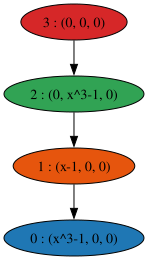

In [9]:
# The adaptive Morse graph as CMGDB draws it (edges point from higher to lower).
CMGDB.PlotMorseGraph(morse_graph)


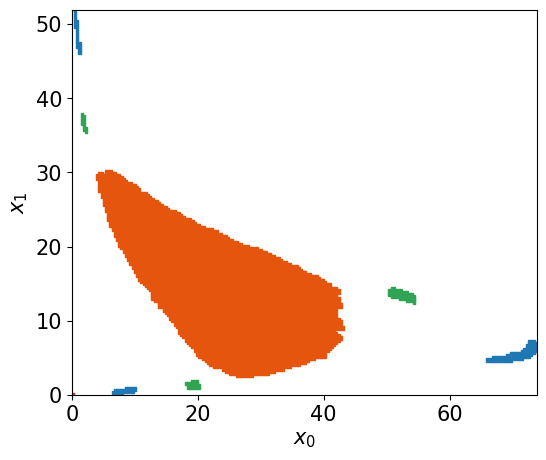

In [10]:
# M3 is the single cell at the origin; M1 is the large recurrent region.
CMGDB.PlotMorseSets(morse_graph, fig_w=6, fig_h=5,
                    xlabel="$x_0$", ylabel="$x_1$")
plt.show()


## The candidate edge

We select the pair to scrutinise by Conley index rather than by integer ID, so
the *selection* does not depend on node numbering.  The fixture assertions
throughout do depend on it, deliberately, so that a change in numbering fails
loudly instead of quietly re-labelling the story.

- **source** — the node with index $(x-1, 0, 0)$, a fixed-point-like set;
- **target** — the node with index $(x^3-1, 0, 0)$, a period-three-like set.

This pair is `(1, 0)` in this run, and it is an edge of the adaptive unreduced
relation.  An edge in the adaptive Morse graph does *not* assert a single-step
map adjacency between the two Morse sets.  It asserts reachability recorded
during the adaptive computation, which for sets separated in the subdivision
hierarchy may have been inherited from a coarser level rather than realised by
any fine-grid path.


In [11]:
def vertex_by_conley_index(mg, annotation):
    """Return the unique Morse node carrying the given Conley index."""
    matches = [
        v for v in range(mg.num_vertices())
        if tuple(mg.annotations(v)) == annotation
    ]
    if len(matches) != 1:
        raise LookupError(
            f"expected exactly one node with Conley index {annotation}, "
            f"found {matches}"
        )
    return matches[0]


SOURCE = vertex_by_conley_index(morse_graph, ("x-1", "0", "0"))
TARGET = vertex_by_conley_index(morse_graph, ("x^3-1", "0", "0"))
CANDIDATE = (SOURCE, TARGET)

assert CANDIDATE == (1, 0), f"candidate pair is {CANDIDATE}, expected (1, 0)"
assert CANDIDATE in adaptive_unreduced, (
    f"{CANDIDATE} is not an adaptive edge: {sorted(adaptive_unreduced)}"
)

print(f"Candidate edge: M{SOURCE} -> M{TARGET}  {CANDIDATE}")


Candidate edge: M1 -> M0  (1, 0)


## Fixed-subdivision verification

`phase_subdiv=s` is the **total binary `TreeGrid` depth**, not a per-coordinate
level: `TreeGrid` splits one coordinate per level, cycling through the
coordinates, so a complete uniform grid at depth $s$ holds $2^{s}$ cells.  In two
dimensions, depths $s$ and $s + 2$ differ by one bisection in each coordinate.

At the depths tested here a complete grid would hold between $2^{16} = 65\,536$
and $2^{20} = 1\,048\,576$ cells, and the corresponding complete `MapGraph`
would be far larger.  The verifier builds neither.  It enumerates each Morse
set's descendants as integer ranges, then expands only the cells its forward
closure actually reaches, evaluating the map lazily through the batch callback.

Both budgets are left unset so every closure runs to exhaustion — only an
exhausted closure can certify `NOT_REACHABLE`.

The lowest depth we test is not arbitrary.  We first confirm that every adaptive
Morse-set leaf sits at depth 16, so $s = 16$ *is* the grid the adaptive
computation finished on; the remaining depths are strictly finer confirmations.


In [12]:
leaf_depths = [
    node["max_adaptive_leaf_depth"]
    for node in CMGDB.ComputeMorseSetReachability(
        model, morse_graph, phase_subdiv=SUBDIV_MIN
    ).provenance()["morse_graph"]["nodes"]
]

assert set(leaf_depths) == {SUBDIV_MIN}, (
    f"adaptive Morse-set leaf depths are {leaf_depths}, expected all "
    f"{SUBDIV_MIN}"
)

print(f"Adaptive Morse-set leaf depths: {leaf_depths}")
print(f"SUBDIV_LIMIT={SUBDIV_LIMIT} halted refinement at depth {SUBDIV_MIN}, "
      f"below SUBDIV_MAX={SUBDIV_MAX};")
print(f"so s={SUBDIV_MIN} is the adaptive computation's own final grid.")


Adaptive Morse-set leaf depths: [16, 16, 16, 16]
SUBDIV_LIMIT=10000 halted refinement at depth 16, below SUBDIV_MAX=20;
so s=16 is the adaptive computation's own final grid.


In [13]:
results = {}
timings = {}

for subdiv in PHASE_SUBDIVISIONS:
    start = time.monotonic()
    results[subdiv] = CMGDB.ComputeMorseSetReachability(
        model,
        morse_graph,
        phase_subdiv=subdiv,
        max_visited_grid_elements=None,
        max_adjacencies_examined=None,
        batch_size=BATCH_SIZE,
        map_fingerprint=MAP_FINGERPRINT,
    )
    timings[subdiv] = time.monotonic() - start

print(f"{'subdiv':>6}  {'M1 -> M0':<14}  {'complete':>8}  "
      f"{'diagnostic':<20}  {'src done':>8}  {'src stop':<8}  absent edges")
print("-" * 100)
for subdiv, result in results.items():
    print(f"{subdiv:>6}  {result.status(*CANDIDATE).name:<14}  "
          f"{str(result.complete()):>8}  {result.diagnostics().name:<20}  "
          f"{str(result.frontier_exhausted(SOURCE)):>8}  "
          f"{result.stop_reason(SOURCE).name:<8}  "
          f"{sorted(map(tuple, result.absent_adaptive_edges()))}")


subdiv  M1 -> M0        complete  diagnostic            src done  src stop  absent edges
----------------------------------------------------------------------------------------------------
    16  NOT_REACHABLE       True  VALID_PARTIAL_ORDER       True  NONE      [(1, 0)]
    17  NOT_REACHABLE       True  VALID_PARTIAL_ORDER       True  NONE      [(1, 0)]
    18  NOT_REACHABLE       True  VALID_PARTIAL_ORDER       True  NONE      [(1, 0)]
    19  NOT_REACHABLE       True  VALID_PARTIAL_ORDER       True  NONE      [(1, 0)]
    20  NOT_REACHABLE       True  VALID_PARTIAL_ORDER       True  NONE      [(1, 0)]


Every row is complete, and every row reports `M1 -> M0` as `NOT_REACHABLE` with
`(1, 0)` the sole absent adaptive edge.  The cost table below totals the work
over all four sources.  Counts grow roughly geometrically with depth, as
expected: refining the grid multiplies the number of cells covering each Morse
set and its closure.  The wall-clock column is indicative only and is not
asserted anywhere.


In [14]:
def totals(result, accessor):
    return sum(accessor(result, v) for v in range(num_vertices))


print(f"{'subdiv':>6}  {'visited':>9}  {'expanded':>9}  {'adjacencies':>12}  "
      f"{'map evals':>10}  {'batches':>8}  {'seconds':>8}")
print("-" * 74)
for subdiv, result in results.items():
    print(f"{subdiv:>6}  "
          f"{totals(result, lambda r, v: r.visited_grid_elements(v)):>9}  "
          f"{totals(result, lambda r, v: r.grid_elements_expanded(v)):>9}  "
          f"{totals(result, lambda r, v: r.adjacencies_examined(v)):>12}  "
          f"{totals(result, lambda r, v: r.map_evaluations_attempted(v)):>10}  "
          f"{totals(result, lambda r, v: r.map_batches_attempted(v)):>8}  "
          f"{timings[subdiv]:>8.2f}")


subdiv    visited   expanded   adjacencies   map evals   batches   seconds
--------------------------------------------------------------------------
    16      21714      21714        137348       21714        62      0.05
    17      40297      40297        253778       40297        80      0.09
    18      75068      75068        482255       75068       109      0.18
    19     141111     141111        901806      141111       150      0.35
    20     267293     267293       1737555      267293       209      0.65


The per-source detail at the finest tested depth shows where the work goes, and
which Morse sets each closure actually reaches.


In [15]:
finest = results[SUBDIV_MAX]
finest_sources = finest.provenance()["sources"]

print(f"Per-source detail at phase_subdiv={SUBDIV_MAX}")
print(f"{'node':>4}  {'Conley index':<18}  {'seeds':>7}  {'visited':>8}  "
      f"{'expanded':>8}  {'adjacencies':>12}  {'stop':<6}  reaches")
print("-" * 96)
for v in range(num_vertices):
    index = "(" + ", ".join(morse_graph.annotations(v)) + ")"
    print(f"{v:>4}  {index:<18}  {finest_sources[v]['fixed_seed_count']:>7}  "
          f"{finest.visited_grid_elements(v):>8}  "
          f"{finest.grid_elements_expanded(v):>8}  "
          f"{finest.adjacencies_examined(v):>12}  "
          f"{finest.stop_reason(v).name:<6}  "
          f"{sorted(finest.adjacencies_unreduced(v))}")


Per-source detail at phase_subdiv=20
node  Conley index          seeds   visited  expanded   adjacencies  stop    reaches
------------------------------------------------------------------------------------------------
   0  (x^3-1, 0, 0)          2528      2528      2528          9264  NONE    []
   1  (x-1, 0, 0)           89120     89120     89120        588547  NONE    []
   2  (0, x^3-1, 0)          1424     75603     75603        497308  NONE    [0, 1]
   3  (0, 0, 0)                16    100042    100042        642436  NONE    [0, 1, 2]


The `visited` column explains the verdict.  For $M_0$ and $M_1$ it equals the
seed count exactly: their forward closures never leave them, so at this
resolution both are **forward invariant** in the fixed combinatorial system.  A
forward-invariant source cannot reach anything outside itself, which is why
$M_1 \rightsquigarrow M_0$ comes back `NOT_REACHABLE` so decisively rather than
by a narrow margin.  By contrast $M_2$ and $M_3$ have closures far larger than
their seeds, and they do reach other Morse sets.


## Correctness assertions

These are the substantive claims of the notebook, checked at every tested depth.
Note in particular that no pair may be `INCOMPLETE`: an `INCOMPLETE` status means
a closure was cut short, and a cut-short closure can never justify removing an
edge.


In [16]:
VERIFIED_UNREDUCED = {(2, 0), (2, 1), (3, 0), (3, 1), (3, 2)}
VERIFIED_REDUCED = {(2, 0), (2, 1), (3, 2)}
ZERO_INSTRUMENTATION = {
    "complete_treegrid_materializations": 0,
    "mapgraph_constructions": 0,
    "complete_vertex_array_bytes": 0,
    "complete_edge_array_bytes": 0,
}

for subdiv, result in results.items():
    assert result.complete(), f"subdivision {subdiv} did not complete"
    assert result.diagnostics() == DIAGNOSTIC.VALID_PARTIAL_ORDER, (
        f"subdivision {subdiv} reports {result.diagnostics().name}"
    )

    for v in range(num_vertices):
        assert result.frontier_exhausted(v), (
            f"subdivision {subdiv}: closure of M{v} not exhausted"
        )
        assert result.stop_reason(v) == STOP_REASON.NONE, (
            f"subdivision {subdiv}: M{v} stopped with "
            f"{result.stop_reason(v).name}"
        )
        assert result.error(v) is None, (
            f"subdivision {subdiv}: M{v} reported {result.error(v)}"
        )
        for w in range(num_vertices):
            assert result.status(v, w) != STATUS.INCOMPLETE, (
                f"subdivision {subdiv}: pair ({v}, {w}) is INCOMPLETE"
            )

    assert result.status(*CANDIDATE) == STATUS.NOT_REACHABLE, (
        f"subdivision {subdiv}: candidate {CANDIDATE} is "
        f"{result.status(*CANDIDATE).name}"
    )
    absent = set(map(tuple, result.absent_adaptive_edges()))
    assert absent == {CANDIDATE}, (
        f"subdivision {subdiv}: absent adaptive edges are {sorted(absent)}"
    )

    strict = {
        (v, w)
        for v in range(num_vertices)
        for w in range(num_vertices)
        if v != w and result.status(v, w) == STATUS.REACHABLE
    }
    assert strict == VERIFIED_UNREDUCED, (
        f"subdivision {subdiv}: verified relation is {sorted(strict)}"
    )

    reduced = {
        (v, w) for v in range(num_vertices) for w in result.adjacencies(v)
    }
    assert reduced == VERIFIED_REDUCED, (
        f"subdivision {subdiv}: verified reduction is {sorted(reduced)}"
    )

    provenance = result.provenance()

    # M0 and M1 are forward invariant: their closures never leave them.
    for v in (SOURCE, TARGET):
        seeds = provenance["sources"][v]["fixed_seed_count"]
        assert result.visited_grid_elements(v) == seeds, (
            f"subdivision {subdiv}: M{v} closure visited "
            f"{result.visited_grid_elements(v)} cells from {seeds} seeds, "
            "so it is not forward invariant"
        )

    assert provenance["verification"]["phase_subdiv"] == subdiv, (
        f"provenance records subdivision "
        f"{provenance['verification']['phase_subdiv']}, expected {subdiv}"
    )
    # Plumbing check only: this echoes the argument passed in, so it confirms
    # the fingerprint reaches provenance intact, not that it identifies the map.
    assert provenance["model"]["map_fingerprint"] == MAP_FINGERPRINT, (
        f"provenance records fingerprint "
        f"{provenance['model']['map_fingerprint']!r}"
    )
    assert provenance["verification"]["instrumentation"] == ZERO_INSTRUMENTATION, (
        f"subdivision {subdiv} materialised structures it must not: "
        f"{provenance['verification']['instrumentation']}"
    )

print(f"All assertions hold at subdivisions "
      f"{PHASE_SUBDIVISIONS[0]}-{PHASE_SUBDIVISIONS[-1]}.")


All assertions hold at subdivisions 16-20.


The verifier is a read-only analysis, so it must leave the `MorseGraph` it was
given untouched.  We check that by comparing a content signature — Morse-set
geometry, Conley indices, and the unreduced relation — taken before and after.


In [17]:
def morse_graph_signature(mg):
    """Content signature of a MorseGraph: geometry, indices, relation."""
    return (
        tuple(
            tuple(sorted(map(tuple, mg.morse_set_boxes(v))))
            for v in range(mg.num_vertices())
        ),
        tuple(tuple(mg.annotations(v)) for v in range(mg.num_vertices())),
        tuple(sorted(mg.edges_unreduced())),
    )


signature_after = morse_graph_signature(morse_graph)

assert set(map(tuple, morse_graph.edges_unreduced())) == adaptive_unreduced, (
    "verification changed the adaptive unreduced relation"
)
assert set(map(tuple, morse_graph.edges())) == adaptive_reduced, (
    "verification changed the adaptive Hasse diagram"
)
assert signature_after == morse_graph_signature(morse_graph), (
    "MorseGraph signature is not stable"
)

print("Input MorseGraph unchanged by verification.")


Input MorseGraph unchanged by verification.


## Cross-check against a complete MapGraph

Avoiding the complete grid is the point of the verifier, but it also makes the
answer harder to audit.  At the coarsest tested depth the complete object is
still small enough to build directly ($2^{16}$ cells), so the lazy answer can be
checked against an independent brute-force closure over a full `MapGraph`.

This cell is evidence, not method: it is not how the verifier works, and it
would be impractical at larger depths or in higher dimensions.  It rests on two
assumptions worth stating.  The provenance `fixed_ranges` are **half-open**
$[\text{first}, \text{last})$ intervals of fixed-grid identifiers, and those
identifiers — the root-to-leaf branch path, most significant branch first —
coincide with the leaf ordering of a complete uniform `TreeGrid` at the same
depth, which is what makes them directly comparable with the reference
`MapGraph`'s cell indices.  The final `adjacencies_examined` comparison is a
deliberate implementation-coupling check on traversal multiplicity rather than a
mathematical invariant; the status and closure-size comparisons above it are the
mathematical content.


In [18]:
CROSSCHECK_SUBDIV = SUBDIV_MIN

reference_model = CMGDB.Model(
    CROSSCHECK_SUBDIV,
    LOWER_BOUNDS,
    UPPER_BOUNDS,
    leslie_box_map,
)
reference_model.set_batch_map(leslie_box_map_batch)

start = time.monotonic()
_, reference_map_graph = CMGDB.ComputeMorseGraph(reference_model)
reference_seconds = time.monotonic() - start

assert reference_map_graph.num_vertices() == 2 ** CROSSCHECK_SUBDIV, (
    f"reference grid has {reference_map_graph.num_vertices()} cells, "
    f"expected {2 ** CROSSCHECK_SUBDIV}"
)

# Fixed-subdivision cells of each Morse set, taken from the provenance ranges.
crosscheck = results[CROSSCHECK_SUBDIV]
morse_cells = [
    {
        cell
        for first, last in node["fixed_ranges"]
        for cell in range(first, last)
    }
    for node in crosscheck.provenance()["morse_graph"]["nodes"]
]

for v in range(num_vertices):
    visited = set(morse_cells[v])
    stack = list(visited)
    examined = 0
    while stack:
        current = stack.pop()
        for successor in reference_map_graph.adjacencies(current):
            examined += 1
            successor = int(successor)
            if successor not in visited:
                visited.add(successor)
                stack.append(successor)

    assert crosscheck.visited_grid_elements(v) == len(visited), (
        f"M{v}: verifier visited {crosscheck.visited_grid_elements(v)} cells, "
        f"brute force visited {len(visited)}"
    )
    assert crosscheck.adjacencies_examined(v) == examined, (
        f"M{v}: verifier examined {crosscheck.adjacencies_examined(v)} "
        f"adjacencies, brute force examined {examined}"
    )
    for w in range(num_vertices):
        expected = (STATUS.REACHABLE if (morse_cells[w] & visited)
                    else STATUS.NOT_REACHABLE)
        assert crosscheck.status(v, w) == expected, (
            f"pair ({v}, {w}): verifier says {crosscheck.status(v, w).name}, "
            f"brute force says {expected.name}"
        )

print(f"Complete MapGraph at depth {CROSSCHECK_SUBDIV}: "
      f"{reference_map_graph.num_vertices()} cells, "
      f"{reference_map_graph.num_cached_edges()} edges, "
      f"{reference_seconds:.1f} s to build.")
print("Lazy verifier agrees with the brute-force closure on every status, "
      "visited count and adjacency count.")


Complete MapGraph at depth 16: 65536 cells, 215410 edges, 0.4 s to build.
Lazy verifier agrees with the brute-force closure on every status, visited count and adjacency count.


## A control run: where the edge comes from

The verifier says the edge is not realised at any fixed depth we tested, and the
counts say $M_1$ is forward invariant.  Both point at the same explanation: the
edge was inherited from a level of the hierarchy coarser than the grid the Morse
sets ended up on.  That explanation makes a sharp, falsifiable prediction — start
the adaptive computation deeper and the edge should never be recorded in the
first place.

We test it by changing `SUBDIV_INIT` from 8 to 16 and nothing else.


In [19]:
control_model = CMGDB.Model(
    SUBDIV_MIN,
    SUBDIV_MAX,
    SUBDIV_MIN,        # SUBDIV_INIT raised from 8 to 16
    SUBDIV_LIMIT,
    LOWER_BOUNDS,
    UPPER_BOUNDS,
    leslie_box_map,
)
control_model.set_batch_map(leslie_box_map_batch)

start = time.monotonic()
control_graph, _ = CMGDB.ComputeConleyMorseGraph(control_model)
control_seconds = time.monotonic() - start

control_unreduced = set(map(tuple, control_graph.edges_unreduced()))
control_cells = [
    len(control_graph.morse_set(v)) for v in range(control_graph.num_vertices())
]
adaptive_cells = [
    len(morse_graph.morse_set(v)) for v in range(num_vertices)
]

# Same Morse sets, same Conley indices, one fewer edge.
assert control_graph.num_vertices() == num_vertices
assert control_cells == adaptive_cells, (
    f"control cell counts {control_cells} differ from {adaptive_cells}"
)
for v in range(num_vertices):
    assert control_graph.annotations(v) == morse_graph.annotations(v), v
assert control_unreduced == adaptive_unreduced - {CANDIDATE}, (
    f"control relation {sorted(control_unreduced)} is not the adaptive "
    f"relation minus {CANDIDATE}"
)
assert control_unreduced == VERIFIED_UNREDUCED, (
    f"control relation {sorted(control_unreduced)} differs from the verified "
    f"relation {sorted(VERIFIED_UNREDUCED)}"
)

print(f"SUBDIV_INIT={SUBDIV_MIN} control run: {control_seconds:.1f} s")
print(f"  Morse sets:  {control_cells} (identical)")
print(f"  relation:    {sorted(control_unreduced)}")
print(f"  adaptive was {sorted(adaptive_unreduced)}")
print(f"  difference:  {sorted(adaptive_unreduced - control_unreduced)}")
print("The control relation equals the verified relation exactly.")


SUBDIV_INIT=16 control run: 0.4 s
  Morse sets:  [158, 5570, 89, 1] (identical)
  relation:    [(2, 0), (2, 1), (3, 0), (3, 1), (3, 2)]
  adaptive was [(1, 0), (2, 0), (2, 1), (3, 0), (3, 1), (3, 2)]
  difference:  [(1, 0)]
The control relation equals the verified relation exactly.


The prediction holds, and sharply.  Raising only `SUBDIV_INIT` yields the same
four Morse sets with the same cell counts and the same Conley indices, but
without the $M_1 \to M_0$ edge — and the resulting relation is *exactly* the
relation the verifier certified.  Two independent routes therefore agree that
the edge is an artifact of the coarse initial grid.

This also tells us what the verifier is worth.  It reaches the same conclusion
without redoing the Conley-index computation, and it does so with an explicit
certificate: an exhausted closure, per-source counters, and a statement about
which pairs are decided.  The control run is the more expensive way to learn the
same thing, and it only works because we could afford to recompute.


## The multi-subdivision study

`ComputeMorseSetReachabilityStudy` repeats the verification at each requested
depth **independently** — no closure, checkpoint, or absence conclusion is
carried from one depth to another — and classifies each ordered pair as
`AGREE_REACHABLE` (every tested depth says `REACHABLE`), `AGREE_NOT_REACHABLE`
(every tested depth says `NOT_REACHABLE`), `UNSTABLE` (completed results
disagree), or `UNRESOLVED` (some result was `INCOMPLETE`).


In [20]:
start = time.monotonic()
study = CMGDB.ComputeMorseSetReachabilityStudy(
    model,
    morse_graph,
    PHASE_SUBDIVISIONS,
    max_visited_grid_elements=None,
    max_adjacencies_examined=None,
    batch_size=BATCH_SIZE,
    map_fingerprint=MAP_FINGERPRINT,
)
study_seconds = time.monotonic() - start

assert study.classification(SOURCE, TARGET) == CMGDB.AGREE_NOT_REACHABLE, (
    f"candidate classified {study.classification(SOURCE, TARGET)}"
)
assert study.prunable_adaptive_edges() == [CANDIDATE], (
    f"prunable edges are {study.prunable_adaptive_edges()}"
)
assert study.unstable_pairs() == [], (
    f"unstable pairs: {study.unstable_pairs()}"
)
assert study.unresolved_pairs() == [], (
    f"unresolved pairs: {study.unresolved_pairs()}"
)

header = "  ".join(f"s={s:<13}" for s in PHASE_SUBDIVISIONS)
print(f"{'pair':<12}  {'adaptive':>8}  {'classification':<22}  {header}")
print("-" * (48 + 15 * len(PHASE_SUBDIVISIONS)))
for v in range(num_vertices):
    for w in range(num_vertices):
        if v == w:
            continue
        row = "  ".join(
            f"{study.result(s).status(v, w).name:<15}"
            for s in PHASE_SUBDIVISIONS
        )
        print(f"{f'M{v} -> M{w}':<12}  "
              f"{str((v, w) in adaptive_unreduced):>8}  "
              f"{study.classification(v, w):<22}  {row}")

print(f"\nStudy of {len(PHASE_SUBDIVISIONS)} subdivisions: "
      f"{study_seconds:.1f} s.")


pair          adaptive  classification          s=16             s=17             s=18             s=19             s=20           
---------------------------------------------------------------------------------------------------------------------------
M0 -> M1         False  AGREE_NOT_REACHABLE     NOT_REACHABLE    NOT_REACHABLE    NOT_REACHABLE    NOT_REACHABLE    NOT_REACHABLE  
M0 -> M2         False  AGREE_NOT_REACHABLE     NOT_REACHABLE    NOT_REACHABLE    NOT_REACHABLE    NOT_REACHABLE    NOT_REACHABLE  
M0 -> M3         False  AGREE_NOT_REACHABLE     NOT_REACHABLE    NOT_REACHABLE    NOT_REACHABLE    NOT_REACHABLE    NOT_REACHABLE  
M1 -> M0          True  AGREE_NOT_REACHABLE     NOT_REACHABLE    NOT_REACHABLE    NOT_REACHABLE    NOT_REACHABLE    NOT_REACHABLE  
M1 -> M2         False  AGREE_NOT_REACHABLE     NOT_REACHABLE    NOT_REACHABLE    NOT_REACHABLE    NOT_REACHABLE    NOT_REACHABLE  
M1 -> M3         False  AGREE_NOT_REACHABLE     NOT_REACHABLE    NOT_REACHABLE    NO

`prunable_adaptive_edges()` implements the `ALL_TESTED_NOT_REACHABLE` policy: it
returns an adaptive edge only when **every** tested depth reported
`NOT_REACHABLE`.  That is agreement over the depths actually tested — it is not
a convergence theorem, and it says nothing about depths outside the tested
range.


## Before and after

`MorseSetReachabilityResult` is *not* a `MorseGraph`: it has no Morse-set grids
or Conley indices, and in general its relation may be incomplete, cyclic, or
non-transitive.  It therefore cannot be handed to `PlotMorseGraph` directly.
Instead we wrap it in a small read-only view exposing the three methods
`PlotMorseGraph` needs, delegating annotations to the original `MorseGraph`.
The original graph is neither mutated nor rebuilt, so both diagrams use the same
node labels, Conley indices, and colours.


In [21]:
class VerifiedGraphView:
    """Read-only PlotMorseGraph view over a reachability result.

    Exposes vertices()/edges()/annotations() only.  Edges come from the
    verified transitive reduction; annotations are delegated to the
    original MorseGraph, which is never modified.
    """

    def __init__(self, result, source_morse_graph):
        self._result = result
        self._morse_graph = source_morse_graph

    def vertices(self):
        return tuple(range(self._result.num_vertices()))

    def edges(self):
        return tuple(
            (v, w)
            for v in self.vertices()
            for w in self._result.adjacencies(v)
        )

    def annotations(self, vertex):
        return self._morse_graph.annotations(vertex)


verified_view = VerifiedGraphView(results[SUBDIV_MAX], morse_graph)

assert verified_view.vertices() == tuple(range(num_vertices))
assert set(verified_view.edges()) == VERIFIED_REDUCED, (
    f"verified view edges are {sorted(verified_view.edges())}"
)

print(f"adaptive Hasse edges: {sorted(adaptive_reduced)}")
print(f"verified Hasse edges: {sorted(verified_view.edges())}")


adaptive Hasse edges: [(1, 0), (2, 1), (3, 2)]
verified Hasse edges: [(2, 0), (2, 1), (3, 2)]


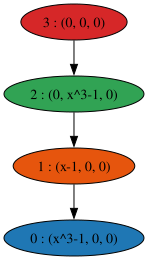

In [22]:
# Adaptive: the chain M3 -> M2 -> M1 -> M0.
CMGDB.PlotMorseGraph(morse_graph)


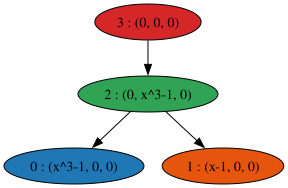

In [23]:
# Verified at depth 20: a fork out of M2, not the chain with one arrow hidden.
CMGDB.PlotMorseGraph(verified_view)


The refined diagram is **not** the adaptive diagram with one arrow erased.  In
the adaptive Hasse diagram $M_2 \to M_0$ is implied by the two-step path through
$M_1$ and is therefore suppressed by the transitive reduction.  Once
$M_1 \rightsquigarrow M_0$ is removed from the *relation* and the reduction is
recomputed, $M_2 \to M_0$ is no longer implied by any two-step path and becomes a
covering edge in its own right.  The diagram changes shape: from a chain to a
fork out of $M_2$.

The figure below overlays the two, drawing the verified relation exactly as
`PlotMorseGraph` renders it and adding the removed adaptive candidate as a
dashed red arrow.


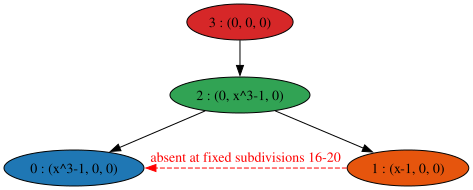

In [24]:
def with_removed_edge(view, removed_edge, label):
    """Overlay a dashed red arrow on the rendered verified Morse graph."""
    body = CMGDB.PlotMorseGraph(view).source.rstrip()
    assert body.endswith("}"), "unexpected graphviz source layout"
    highlight = (
        f'{removed_edge[0]} -> {removed_edge[1]} '
        f'[style=dashed, color=red, fontcolor=red, constraint=false, '
        f'label="{label}"];\n'
    )
    return graphviz.Source(body[:-1] + highlight + "}\n")


with_removed_edge(
    verified_view,
    CANDIDATE,
    f"absent at fixed subdivisions "
    f"{PHASE_SUBDIVISIONS[0]}-{PHASE_SUBDIVISIONS[-1]}",
)


## Interpretation

**What was shown.**  The adaptive Morse graph records
$M_1 \rightsquigarrow M_0$, an edge inherited from a coarser level of the
subdivision hierarchy, where reachability propagates to descendant Morse sets as
a cross product whether or not any finer path realises it.  Exhaustive forward
closures on the fixed uniform grids at depths $16, \dots, 20$ all return
`NOT_REACHABLE` for that pair, with every closure exhausted, no budget reached,
and no error.  Depth 16 is the grid the adaptive computation itself finished on,
so this is a refutation on the decomposition's own resolution, not only on finer
ones.  The mechanism is visible in the counts: at every tested depth the closure
of $M_1$ is exactly $M_1$, so $M_1$ is forward invariant in the fixed
combinatorial system and reaches no Morse set other than itself.  Under the
stated `ALL_TESTED_NOT_REACHABLE` policy the edge is therefore prunable, and
removing it turns the Hasse diagram from a chain into a fork.

**Independently corroborated.**  Raising `SUBDIV_INIT` from 8 to 16 and changing
nothing else reproduces the same four Morse sets, cell for cell, with the same
Conley indices — and never records the edge.  The relation that control run
produces is exactly the relation the verifier certified.

**What the two verdicts mean.**  `REACHABLE` means a combinatorial path exists
in that particular fixed outer approximation; because the box map is an outer
enclosure, such a path may be an artifact of the discretisation and need not
correspond to any true orbit.  `NOT_REACHABLE` means the complete forward
closure of the source in that fixed outer approximation was exhausted without
ever encountering a cell of the target — a statement about one combinatorial
system at one depth.

**What this does not establish.**

- **It does not prove nonreachability for the true Leslie dynamics.**  The
  implication runs one way only.  An orbit that stays inside the truncated phase
  space and connects the two regions would force a combinatorial path in any
  valid outer approximation — and the enclosure used here is one, since each
  candidate is widened by a certified error bound whose magnitude is some
  fifteen orders below a cell width — so `NOT_REACHABLE` does rule out such an
  orbit between the cells covering these Morse sets at that depth.  Two gaps remain
  even then.  First, the Morse sets are themselves outer approximations of the
  underlying invariant sets, so a statement about the cells covering them is
  weaker than a statement about the invariant sets.  Second, the phase space
  here is a truncation that is **not** forward invariant — as computed above,
  the first component of the image dips below the lower bound near the domain
  corner — so `cover` clips escaping images and the combinatorial system does not
  track an orbit that leaves the box and returns.  What we have is evidence
  about the discretised system, not a theorem about the continuous one.
- The result is a **reachability graph over the existing Morse sets**, not a new
  Morse decomposition.  No Morse set was recomputed, split, merged, or
  re-indexed, and no Conley index was recomputed.
- It **cannot exclude undiscovered recurrent components**.  The closures traverse
  cells outside the supplied Morse sets, and cycles among those cells are simply
  traversed; the verifier neither identifies nor rules them out.  A recurrent
  component missed by the adaptive computation stays missed here.
- **Reachability is not monotone in subdivision.**  A pair can be `REACHABLE` at
  one depth and `NOT_REACHABLE` at another, in either direction, which is why
  the study reports `UNSTABLE` rather than preferring the finest result.  That
  all five depths agree here is an observation about this example, not a general
  guarantee, and agreement over five depths is not a limit statement.

**Relation to spurious Morse sets.**  Other tutorials discuss *spurious transient
Morse sets*: extra nodes, typically with **trivial Conley index**, that appear
because a coarse grid cannot separate nearby trajectories.  That is a defect in
the **vertices** of the Morse graph, and the remedy is a finer or better-chosen
subdivision.

The defect here sits in a different place — a single **edge**, with both
endpoints genuine and carrying **nontrivial** Conley indices, $(x-1, 0, 0)$ and
$(x^3-1, 0, 0)$ — but it would be wrong to call it a different *kind* of problem.
The control run shows it has the same origin and the same remedy: a coarse
initial grid, cured by starting deeper.  A related standard diagnostic points the
same way, and the notebook has been silent about it — $M_1$ carries an
attractor-type index $(x-1, 0, 0)$ yet is not minimal in the adaptive graph,
which is itself a signal that `SUBDIV_INIT` was too coarse.

What distinguishes the verifier is not the kind of defect it addresses but what
it costs and what it produces.  It *detects and certifies* the absent edge on the
existing decomposition, with an explicit certificate, without recomputing the
Morse sets or their Conley indices — which is the operative difference when the
decomposition was expensive and re-running it at a finer initial depth is not
affordable.  It never questions a vertex.

For completeness, this Morse graph does also contain a trivial-index node.
$M_3$ is the single cell at the domain corner containing the extinction fixed
point, and its reported index is $(0, 0, 0)$.  A trivial index at a cell sitting
in the corner of a truncated, non-forward-invariant domain is unsurprising, but
this notebook does not investigate it; the observation here is only that $M_3$ is
exactly the kind of node the other tutorials scrutinise, and that it is *not* an
endpoint of the edge pruned here.
